# Random 5P-Pred Click Curves by Dataset

This notebook plots **dataset-level click curves** for the **5P-Pred** regime under the **random** policy.

Computation follows the intended hierarchy:
1. For each subset and displayed image index, average the per-click metric across permutations.
2. Within each task, bootstrap subset curves with replacement.
3. Average bootstrapped task curves to obtain a dataset-level mean curve and 95% CI.

Edit `DISPLAY_IMAGE_INDICES` in the config cell to choose which image positions to display.

In [2]:
from pathlib import Path 
import sys

repo_root = Path("/data/ddmg/mvseg-ordering")
for path in [repo_root, repo_root / "UniverSeg", repo_root / "MultiverSeg", repo_root / "ScribblePrompt",]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

In [3]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator, MultipleLocator

from experiments.analysis.hierarchical_ci import hierarchical_bootstrap_curve_2d
from experiments.analysis.notebook_plot_style import (
    FONT_SIZE_LEGEND,
    FONT_SIZE_PANEL_TITLE,
    FONT_SIZE_SUPTITLE,
    FONT_SIZE_XLABEL,
    FONT_SIZE_XTICKS,
    FONT_SIZE_YLABEL,
    FONT_SIZE_YTICKS,
)
from experiments.analysis.planb_click_curves import build_task_curves_by_image
from experiments.analysis.planb_utils import iter_planb_subset_dirs

In [4]:
# -----------------------------
# Config
# -----------------------------
REPO_ROOT = Path('/data/ddmg/mvseg-ordering')

# Default notebook target: final-paper random policy in the 5P-Pred regime.
PROCEDURE = 'random_v2'
ABLATION = 'pretrained_baseline_gt'
POLICY_NAME = 'random'

# Edit this list to choose which image positions are shown.
DISPLAY_IMAGE_INDICES = [0, 1, 2, 4, 9]
FAMILY_DISPLAY = {'T1mix': 'COBRE'}
LEGEND_ONE_INDEXED = True

N_BOOT = 1000
SEED = 23

N_COLS = 3
Y_LIM = None

SAVE_FIGURE = False
OUT_DIR = REPO_ROOT / 'figures' / 'random_5ppred_click_curves_dataset_grid'
OUT_NAME = f"{PROCEDURE.replace('/', '_')}_{ABLATION}_{POLICY_NAME}_click_curves_dataset_grid.png"

In [5]:
def legend_label_from_index(image_index: int, one_indexed: bool = True) -> str:
    shown_index = image_index + 1 if one_indexed else image_index
    return f'Position {shown_index}'


def collect_subset_entries(*, repo_root: Path, procedure: str, ablation: str, policy_name: str) -> list[dict[str, object]]:
    entries = list(
        iter_planb_subset_dirs(
            repo_root=repo_root,
            procedure=procedure,
            ablation=ablation,
            policy=policy_name,
            include_families=None,
        )
    )
    if not entries:
        raise FileNotFoundError(
            f'No Plan B subset dirs found for procedure={procedure}, ablation={ablation}, policy={policy_name}'
        )
    return entries


def bootstrap_family_curves(
    family_entries: list[dict[str, object]],
    image_indices: list[int],
    *,
    n_boot: int,
    seed: int,
) -> dict[int, dict[str, pd.Series]]:
    # build_task_curves_by_image does the within-subset averaging across permutations
    # for each requested image index.
    per_image_tables = build_task_curves_by_image(family_entries, image_indices)
    out: dict[int, dict[str, pd.Series]] = {}
    for image_index in image_indices:
        task_tables = per_image_tables.get(int(image_index), {})
        if not task_tables:
            continue
        boot = hierarchical_bootstrap_curve_2d(task_tables, n_boot=n_boot, seed=seed)
        out[int(image_index)] = {
            'mean': boot['mean'],
            'ci_lo': boot['ci_lo'],
            'ci_hi': boot['ci_hi'],
        }
    return out

In [6]:
entries = collect_subset_entries(
    repo_root=REPO_ROOT,
    procedure=PROCEDURE,
    ablation=ABLATION,
    policy_name=POLICY_NAME,
)

families = sorted({str(meta['family']) for meta in entries})
print('Families found:', families)
print('Total subset dirs:', len(entries))

family_to_entries: dict[str, list[dict[str, object]]] = {family: [] for family in families}
for meta in entries:
    family_to_entries[str(meta['family'])].append(meta)

family_boot: dict[str, dict[int, dict[str, pd.Series]]] = {}
for family in families:
    family_entries = family_to_entries[family]
    family_boot[family] = bootstrap_family_curves(
        family_entries,
        DISPLAY_IMAGE_INDICES,
        n_boot=N_BOOT,
        seed=SEED,
    )
    print(f'[done] {family}: subset_dirs={len(family_entries)} image_curves={sorted(family_boot[family].keys())}')

Families found: ['ACDC', 'BTCV', 'BUID', 'HipXRay', 'PanDental', 'SCD', 'SCR', 'T1mix', 'TotalSegmentator', 'WBC']
Total subset dirs: 1630
[done] ACDC: subset_dirs=60 image_curves=[0, 1, 2, 4, 9]
[done] BTCV: subset_dirs=200 image_curves=[0, 1, 2, 4, 9]
[done] BUID: subset_dirs=40 image_curves=[0, 1, 2, 4, 9]
[done] HipXRay: subset_dirs=40 image_curves=[0, 1, 2, 4, 9]
[done] PanDental: subset_dirs=40 image_curves=[0, 1, 2, 4, 9]
[done] SCD: subset_dirs=40 image_curves=[0, 1, 2, 4, 9]
[done] SCR: subset_dirs=200 image_curves=[0, 1, 2, 4, 9]
[done] T1mix: subset_dirs=460 image_curves=[0, 1, 2, 4, 9]
[done] TotalSegmentator: subset_dirs=470 image_curves=[0, 1, 2, 4, 9]
[done] WBC: subset_dirs=80 image_curves=[0, 1, 2, 4, 9]


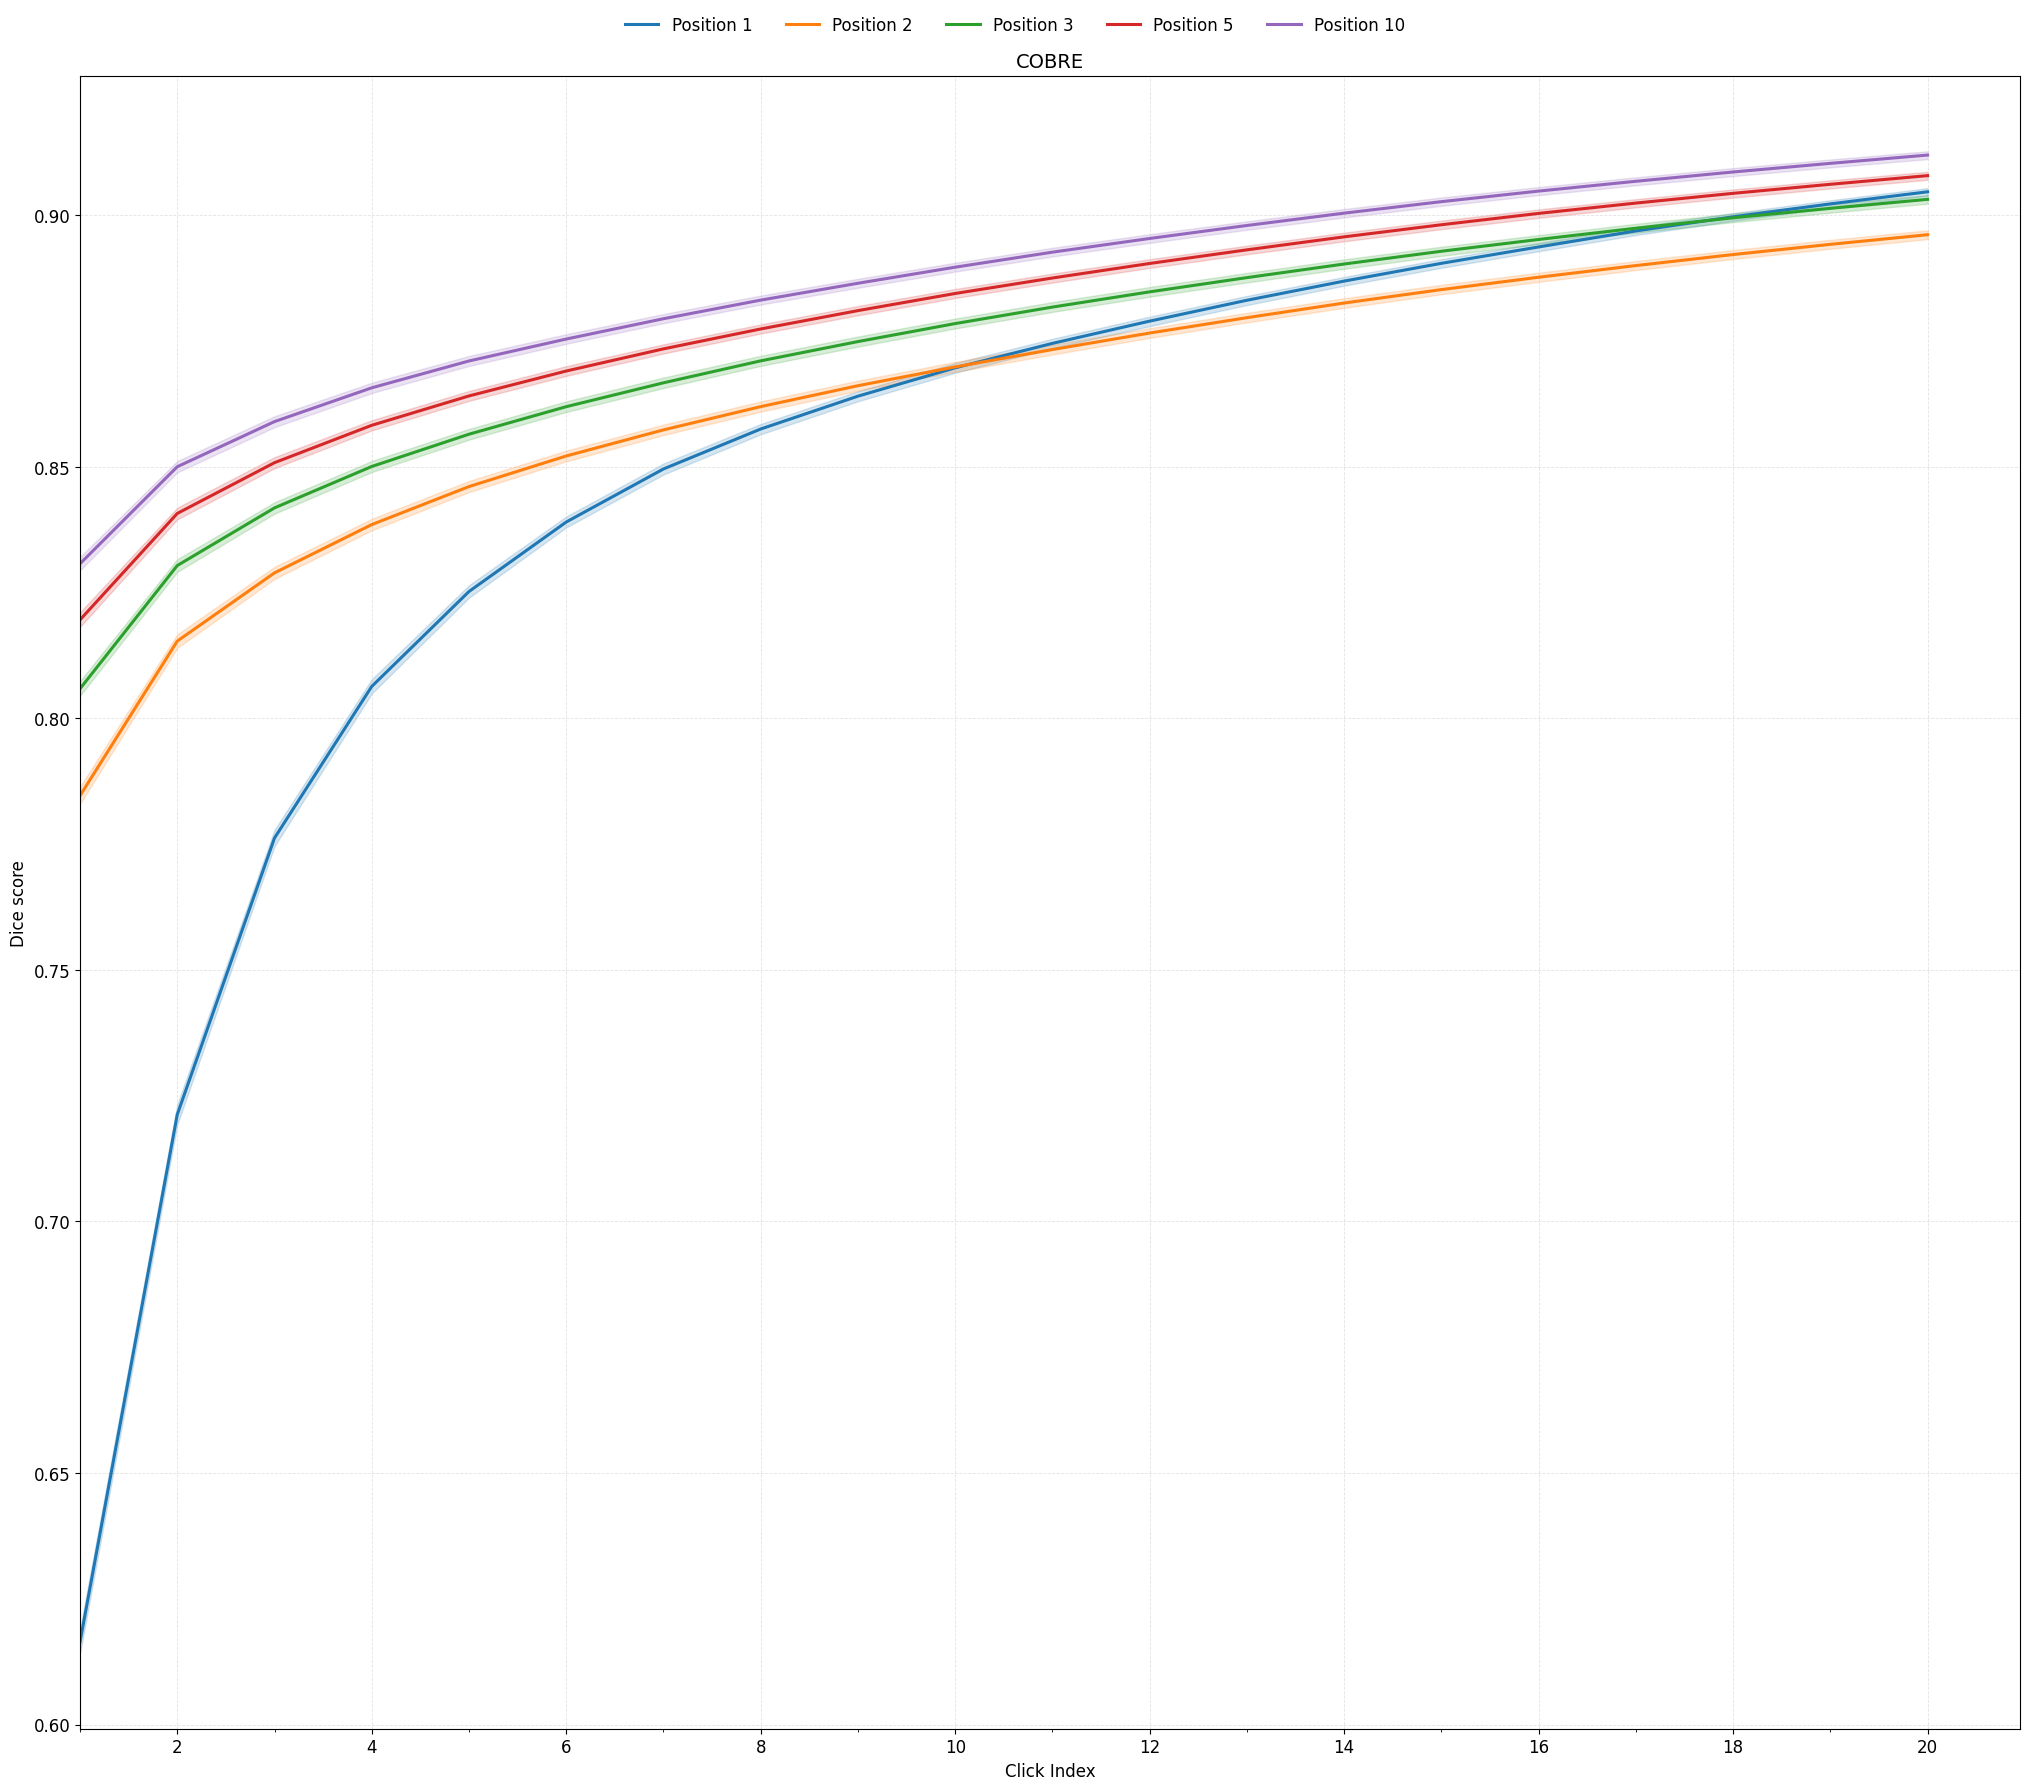

In [ ]:
families_with_curves = [family for family in families if family_boot.get(family)]
if not families_with_curves:
    raise RuntimeError('No families had bootstrapped curves to plot.')

n_cols = max(1, int(N_COLS))
n_rows = int(math.ceil(len(families_with_curves) / n_cols))

fig, axes = plt.subplots(
    1,
    1,
    figsize=(6.8 * n_cols, 4.6 * n_rows),
    squeeze=False,
)
axes_flat = axes.ravel()
cmap = plt.get_cmap('tab10')

for ax_idx, family in enumerate(["T1mix"]):
    ax = axes_flat[ax_idx]
    boot_by_image = family_boot[family]

    for color_idx, image_index in enumerate(DISPLAY_IMAGE_INDICES):
        if int(image_index) not in boot_by_image:
            continue
        curve = boot_by_image[int(image_index)]
        mean_curve = curve['mean']
        lo_curve = curve['ci_lo']
        hi_curve = curve['ci_hi']
        color = cmap(color_idx % 10)
        label = legend_label_from_index(int(image_index), one_indexed=LEGEND_ONE_INDEXED)

        plot_mask = mean_curve.index >= 0
        x_plot = mean_curve.index[plot_mask] + 1
        mean_plot = mean_curve.values[plot_mask]
        lo_plot = lo_curve.values[plot_mask]
        hi_plot = hi_curve.values[plot_mask]

        ax.plot(x_plot, mean_plot, linewidth=2.2, color=color, label=label)
        ax.fill_between(x_plot, lo_plot, hi_plot, alpha=0.18, color=color)

    ax.set_title(FAMILY_DISPLAY.get(family, family), fontsize=FONT_SIZE_PANEL_TITLE)
    ax.set_xlabel('Click Index', fontsize=FONT_SIZE_XLABEL)
    ax.set_ylabel('Dice score', fontsize=FONT_SIZE_YLABEL)
    ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.35)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.tick_params(axis='x', labelsize=FONT_SIZE_XTICKS)
    ax.tick_params(axis='y', labelsize=FONT_SIZE_YTICKS)
    if Y_LIM is not None:
        ax.set_ylim(*Y_LIM)
    ax.set_xlim(left=1)

for ax in axes_flat[len(families_with_curves):]:
    ax.axis('off')

handles, labels = axes_flat[0].get_legend_handles_labels()
if handles:
    fig.legend(
        handles,
        labels,
        loc='upper center',
        ncol=min(len(labels), len(DISPLAY_IMAGE_INDICES)),
        frameon=False,
        fontsize=FONT_SIZE_LEGEND,
        bbox_to_anchor=(0.5, 0.975),
    )

# fig.suptitle(
#     'Hierarchical Click Curves by Dataset for the Random 5P-Pred Regime',
#     fontsize=FONT_SIZE_SUPTITLE + 2,
#     y=0.995,
# )
fig.tight_layout(rect=(0, 0, 1, 0.955))

if SAVE_FIGURE:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    out_path = OUT_DIR / OUT_NAME
    fig.savefig(out_path, dpi=220, bbox_inches='tight')
    print(f'Saved: {out_path}')

plt.show()